# Classical Machine Learning Baselines

This notebook establishes the classical machine-learning baselines for the
UNSW-NB15 binary intrusion-detection task.

The previous preprocessing experiments produced multiple candidate feature
representations designed to address differences in feature scale, skewness,
outliers, and redundancy.

Rather than assuming that a particular preprocessing strategy is optimal, this
notebook evaluates the candidate preprocessing variants using classical
machine-learning models.

The objectives are to:

1. Establish strong classical baseline performance.
2. Compare the effect of different preprocessing strategies.
3. Identify which model-preprocessing combinations are most effective.
4. Establish a benchmark for the later constrained QML and hybrid-model stages.

All models will be evaluated using the same official training and testing
splits to ensure a consistent comparison.

## 1. Imports and Configuration

This section imports the libraries required for data loading, preprocessing,
model training, and evaluation.

In [78]:
#importing libraries 
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    RobustScaler,
    FunctionTransformer
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from src.data.preprocessing import UNSWPreprocessor

from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.model_selection import RandomizedSearchCV

from scipy.sparse import issparse

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

## 2. Project Path Configuration

The notebook is executed from the `notebooks/03_baseline_models` directory,
while the dataset and preprocessing utilities are located elsewhere in the
project structure.

The project root is therefore added to the Python path so that project modules
and data files can be accessed consistently.

In [2]:
#notebook config
PROJECT_ROOT = Path.cwd().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:")
print(PROJECT_ROOT)

Project root:
c:\Projects\Aeges-Q


## 3. Loading the Dataset

The official UNSW-NB15 training and testing splits are loaded for baseline
model development.

The original splits are preserved to maintain consistency with the previous
EDA and preprocessing experiments. No additional train-test split is created.

The `label` column is used as the binary target, while `attack_cat` is retained
only as metadata and is not used as a model input feature.

In [4]:
train_path = PROJECT_ROOT / "data" / "raw" / "UNSW_NB15_training-set.csv"
test_path = PROJECT_ROOT / "data" / "raw" / "UNSW_NB15_testing-set.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Training set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)

Training set shape: (82332, 45)
Testing set shape: (175341, 45)


## 4. Feature and Target Preparation

The raw dataset contains an identifier column, the binary classification target,
and attack-category metadata.

To maintain consistency with the preprocessing experiments, the existing
`UNSWPreprocessor` utility is used to separate:

- Model input features (`X`)
- Binary target labels (`y`)
- Attack-category metadata

Only the binary `label` is used for the baseline classification experiments.
The `attack_cat` column is retained separately for potential later analysis.

In [5]:
preprocessor = UNSWPreprocessor()

X_train, y_train, attack_train = (
    preprocessor.split_features_and_target(train_df)
)

X_test, y_test, attack_test = (
    preprocessor.split_features_and_target(test_df)
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nX_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (82332, 42)
y_train: (82332,)

X_test: (175341, 42)
y_test: (175341,)


## 5. Evaluation Framework

All model-preprocessing combinations will be evaluated using the same set of
classification metrics.

Because intrusion detection involves identifying malicious traffic, accuracy
alone is insufficient. The evaluation therefore includes:

- **Accuracy:** Overall proportion of correctly classified samples.
- **Precision:** Proportion of predicted attacks that are actually attacks.
- **Recall:** Proportion of actual attacks correctly detected.
- **F1-score:** Harmonic mean of precision and recall.
- **ROC-AUC:** Ability of the model to distinguish between normal and attack
  traffic across different classification thresholds.

Using a common evaluation framework ensures that all preprocessing and model
combinations can be compared consistently.

In [6]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    y_proba = model.predict_proba(X_test)[:, 1]

    results = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba)
    }

    return results

## 6. Preprocessing Setup

This section reconstructs the preprocessing variants developed in the previous
notebook so they can be evaluated consistently across the baseline models.
Each transformer is fitted only on the training data before being applied to
the testing data.

In [7]:
preprocessor.identify_feature_types(X_train)

numerical_features = preprocessor.numerical_features
categorical_features = preprocessor.categorical_features

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

print("\nCategorical features:")
print(categorical_features)

Numerical features: 39
Categorical features: 3

Categorical features:
['proto', 'service', 'state']


In [8]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

In [9]:
# base numerical pipeline 
base_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

In [10]:
# standard-scaled numerical pipeline 
standard_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [11]:
# robust-scaled numerical pipeline
robust_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler())
    ]
)

In [12]:
# piepline 
preprocessing_variants = {}

preprocessing_variants["A"] = ColumnTransformer(
    transformers=[
        ("numeric", base_numeric_transformer, numerical_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

preprocessing_variants["B"] = ColumnTransformer(
    transformers=[
        ("numeric", standard_numeric_transformer, numerical_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

preprocessing_variants["C"] = ColumnTransformer(
    transformers=[
        ("numeric", robust_numeric_transformer, numerical_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

In [13]:
# D1-Broad Log Transform 
broad_log_features = [
    "dur",
    "spkts",
    "dpkts",
    "sbytes",
    "dbytes",
    "rate",
    "sload",
    "dload",
    "sloss",
    "dloss",
    "sinpkt",
    "dinpkt",
    "sjit",
    "djit",
    "tcprtt",
    "synack",
    "ackdat",
    "smean",
    "dmean",
    "trans_depth",
    "response_body_len",
    "ct_srv_src",
    "ct_state_ttl",
    "ct_dst_ltm",
    "ct_src_dport_ltm",
    "ct_dst_sport_ltm",
    "ct_dst_src_ltm",
    "is_ftp_login",
    "ct_ftp_cmd",
    "ct_flw_http_mthd",
    "ct_src_ltm",
    "ct_srv_dst",
    "is_sm_ips_ports"
]

remaining_d1_features = [
    feature
    for feature in numerical_features
    if feature not in broad_log_features
]

In [14]:
log_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p)),
        ("scaler", StandardScaler())
    ]
)

In [15]:
preprocessing_variants["D1"] = ColumnTransformer(
    transformers=[
        (
            "log_numeric",
            log_numeric_transformer,
            broad_log_features
        ),
        (
            "remaining_numeric",
            standard_numeric_transformer,
            remaining_d1_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [16]:
# selective log transformation
selective_log_features = [
    "dur",
    "spkts",
    "dpkts",
    "sbytes",
    "dbytes",
    "rate",
    "sload",
    "dload",
    "sloss",
    "dloss",
    "sinpkt",
    "dinpkt",
    "sjit",
    "djit",
    "tcprtt",
    "synack",
    "ackdat",
    "smean",
    "dmean",
    "trans_depth",
    "response_body_len",
    "ct_srv_src",
    "ct_state_ttl",
    "ct_dst_ltm",
    "ct_src_dport_ltm",
    "ct_dst_sport_ltm",
    "ct_dst_src_ltm",
    "ct_flw_http_mthd",
    "ct_src_ltm",
    "ct_srv_dst"
]

remaining_d2_features = [
    feature
    for feature in numerical_features
    if feature not in selective_log_features
]

In [17]:
preprocessing_variants["D2"] = ColumnTransformer(
    transformers=[
        (
            "log_numeric",
            log_numeric_transformer,
            selective_log_features
        ),
        (
            "remaining_numeric",
            standard_numeric_transformer,
            remaining_d2_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [18]:
# redundancy reduction
features_to_drop = [
    "ct_dst_ltm",
    "ct_dst_src_ltm",
    "ct_ftp_cmd",
    "ct_src_dport_ltm",
    "ct_src_ltm",
    "ct_srv_src",
    "dloss",
    "dpkts",
    "dwin",
    "is_sm_ips_ports",
    "sloss",
    "spkts",
    "tcprtt"
]

In [19]:
reduced_numerical_features = [
    feature
    for feature in numerical_features
    if feature not in features_to_drop
]

In [20]:
print("Original numerical features:", len(numerical_features))
print("Reduced numerical features:", len(reduced_numerical_features))

Original numerical features: 39
Reduced numerical features: 26


In [21]:
preprocessing_variants["E"] = ColumnTransformer(
    transformers=[
        (
            "numeric",
            standard_numeric_transformer,
            reduced_numerical_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

## 7. Generating Preprocessed Feature Representations

Each preprocessing variant is fitted exclusively on the training data and then
used to transform both the training and testing sets.

The resulting feature matrices are stored so that every baseline model can be
evaluated on exactly the same preprocessing variants.

In [22]:
processed_data = {}

In [23]:
for variant_name, transformer in preprocessing_variants.items():

    print(f"Processing Variant {variant_name}...")

    X_train_processed = transformer.fit_transform(X_train)

    X_test_processed = transformer.transform(X_test)

    processed_data[variant_name] = {
        "X_train": X_train_processed,
        "X_test": X_test_processed
    }

    print(
        "Train shape:",
        X_train_processed.shape
    )

    print(
        "Test shape:",
        X_test_processed.shape
    )

    print()

Processing Variant A...


Train shape: (82332, 190)
Test shape: (175341, 190)

Processing Variant B...
Train shape: (82332, 190)
Test shape: (175341, 190)

Processing Variant C...
Train shape: (82332, 190)
Test shape: (175341, 190)

Processing Variant D1...
Train shape: (82332, 190)
Test shape: (175341, 190)

Processing Variant D2...
Train shape: (82332, 190)
Test shape: (175341, 190)

Processing Variant E...
Train shape: (82332, 177)
Test shape: (175341, 177)



In [24]:
for variant_name, data in processed_data.items():

    print(
        f"{variant_name}:",
        "Train =", data["X_train"].shape,
        "| Test =", data["X_test"].shape
    )

A: Train = (82332, 190) | Test = (175341, 190)
B: Train = (82332, 190) | Test = (175341, 190)
C: Train = (82332, 190) | Test = (175341, 190)
D1: Train = (82332, 190) | Test = (175341, 190)
D2: Train = (82332, 190) | Test = (175341, 190)
E: Train = (82332, 177) | Test = (175341, 177)


## 8. Baseline Model Benchmarking

Each preprocessing variant is evaluated using the same classical machine-learning
models.

The initial baselines consist of:

- **Logistic Regression**, providing a linear baseline and allowing the effect
  of feature scaling and transformation to be examined.
- **Random Forest**, providing a nonlinear tree-based baseline that is less
  sensitive to feature scaling.

Each model-preprocessing combination is trained on the official training split
and evaluated on the official testing split using the common evaluation
framework defined earlier.

In [25]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

In [26]:
# benchmark loop 
benchmark_results = []

for variant_name, data in processed_data.items():

    X_train_variant = data["X_train"]
    X_test_variant = data["X_test"]

    for model_name, model in models.items():

        print(
            f"Training {model_name} "
            f"on Variant {variant_name}..."
        )

        model.fit(
            X_train_variant,
            y_train
        )

        results = evaluate_model(
            model,
            X_test_variant,
            y_test
        )

        results["variant"] = variant_name
        results["model"] = model_name

        benchmark_results.append(results)

        print(
            f"F1 Score: {results['f1_score']:.4f}"
        )

        print()

Training Logistic Regression on Variant A...


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


F1 Score: 0.7749

Training Random Forest on Variant A...
F1 Score: 0.9252

Training Logistic Regression on Variant B...
F1 Score: 0.9032

Training Random Forest on Variant B...
F1 Score: 0.9254

Training Logistic Regression on Variant C...


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


F1 Score: 0.8630

Training Random Forest on Variant C...
F1 Score: 0.9251

Training Logistic Regression on Variant D1...
F1 Score: 0.9150

Training Random Forest on Variant D1...
F1 Score: 0.9254

Training Logistic Regression on Variant D2...
F1 Score: 0.9150

Training Random Forest on Variant D2...
F1 Score: 0.9251

Training Logistic Regression on Variant E...
F1 Score: 0.9155

Training Random Forest on Variant E...
F1 Score: 0.9335



In [27]:
results_df = pd.DataFrame(benchmark_results)

results_df = results_df[
    [
        "variant",
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc"
    ]
]

results_df

,variant,model,accuracy,precision,recall,f1_score,roc_auc
0,A,Logistic Regression,0.740665,0.946722,0.655885,0.774913,0.899339
1,A,Random Forest,0.904272,0.987758,0.870137,0.925224,0.983710
2,B,Logistic Regression,0.877678,0.978596,0.838622,0.903218,0.977851
3,B,Random Forest,0.904472,0.987614,0.870564,0.925402,0.983601
4,C,Logistic Regression,0.824856,0.922805,0.810467,0.862996,0.926834
5,C,Random Forest,0.904164,0.987672,0.870053,0.925139,0.983631
6,D1,Logistic Regression,0.892073,0.986267,0.853311,0.914984,0.982187
7,D1,Random Forest,0.904415,0.987668,0.870430,0.925351,0.982915
8,D2,Logistic Regression,0.892147,0.986287,0.853403,0.915046,0.982134
9,D2,Random Forest,0.904078,0.987578,0.870011,0.925074,0.983236


## 9. Benchmark Results Visualization

The benchmark results are visualized to compare the effect of each preprocessing
strategy across the two baseline models.

The visualizations focus on F1-score as the primary balance between precision
and recall, while the complete metric comparison is retained in the results
table.

In [28]:
variant_order = ["A", "B", "C", "D1", "D2", "E"]

results_df["variant"] = pd.Categorical(
    results_df["variant"],
    categories=variant_order,
    ordered=True
)

results_df = results_df.sort_values(
    ["model", "variant"]
)

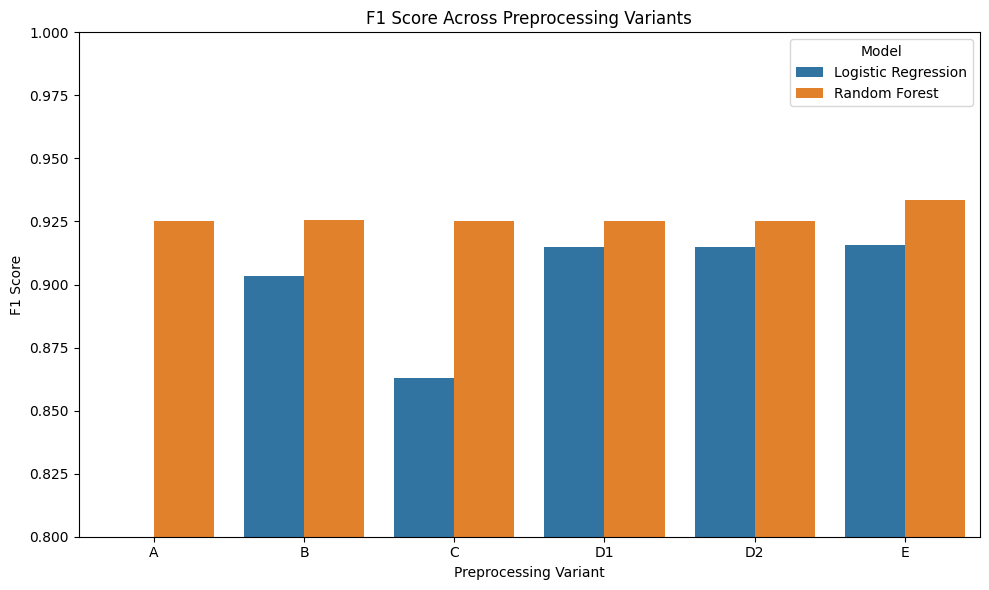

In [29]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="variant",
    y="f1_score",
    hue="model"
)

plt.title("F1 Score Across Preprocessing Variants")
plt.xlabel("Preprocessing Variant")
plt.ylabel("F1 Score")
plt.ylim(0.80, 1.00)

plt.legend(title="Model")

plt.tight_layout()
plt.show()

In [30]:
rf_results = results_df[
    results_df["model"] == "Random Forest"
]

rf_metrics = rf_results.melt(
    id_vars="variant",
    value_vars=[
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc"
    ],
    var_name="metric",
    value_name="score"
)

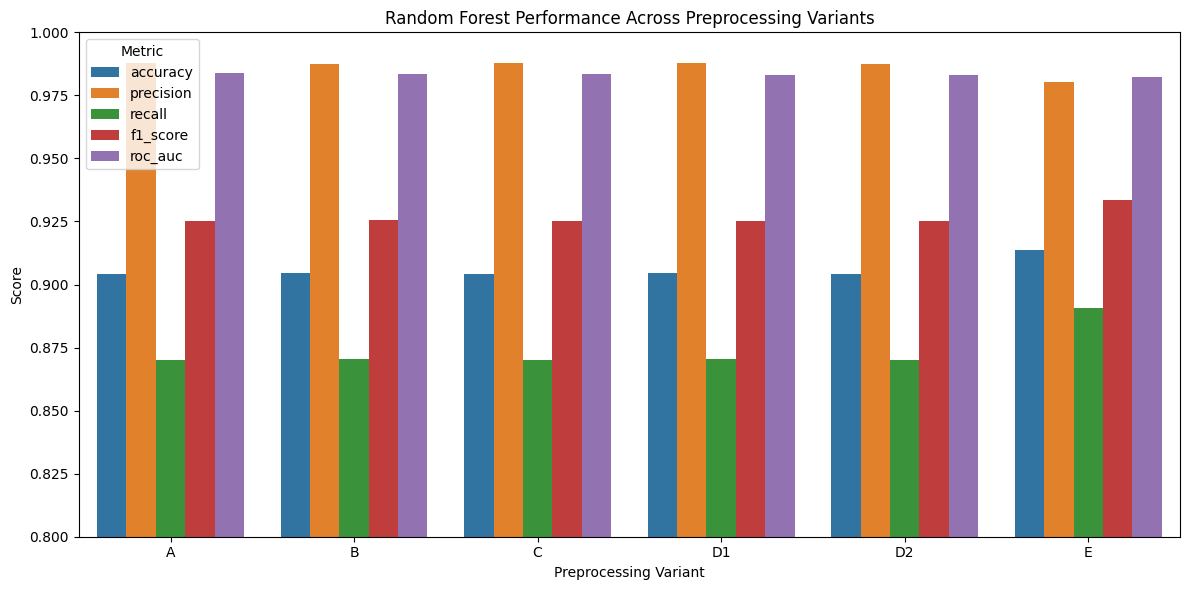

In [31]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=rf_metrics,
    x="variant",
    y="score",
    hue="metric"
)

plt.title(
    "Random Forest Performance Across Preprocessing Variants"
)

plt.xlabel("Preprocessing Variant")
plt.ylabel("Score")

plt.ylim(0.80, 1.00)

plt.legend(title="Metric")

plt.tight_layout()
plt.show()

## 10. Benchmark Findings and Preprocessing Selection

The six preprocessing variants were evaluated using Logistic Regression and
Random Forest classifiers across accuracy, precision, recall, F1-score, and
ROC-AUC.

The experiments show that preprocessing strategy has a measurable impact on
model performance. Scaling and logarithmic transformation improved performance
in several cases, but the strongest overall results were obtained using
**Variant E**, which applies correlation-based redundancy reduction.

Variant E reduced the processed feature space from **190 features to 177
features** by removing 13 features identified as highly redundant through
correlation analysis. Representative features from correlated groups were
retained based on their mutual information with the target variable.

Despite using fewer features, Variant E produced the strongest overall
performance among the evaluated preprocessing strategies. It achieved the best
F1-score for both baseline models and produced the strongest Random Forest
results across the evaluated metrics.

This suggests that reducing redundant information was more beneficial for this
dataset than applying scaling or broad logarithmic transformations alone.

Therefore, **Variant E is selected as the primary preprocessing strategy for
subsequent experiments**.

The remaining preprocessing variants are retained as experimental evidence and
provide a comparative baseline demonstrating the effect of different feature
transformation strategies.

## 11. Advanced Classical Model Benchmarking

After selecting Variant E as the primary preprocessing strategy, stronger
classical machine-learning models are evaluated using the reduced feature
representation.

This stage compares models with different learning characteristics against the
previous Logistic Regression and Random Forest baselines. The objective is to
determine whether more advanced ensemble and boosting approaches can improve
classification performance on the UNSW-NB15 dataset.

In [32]:
X_train_E = processed_data["E"]["X_train"]
X_test_E = processed_data["E"]["X_test"]

print("Variant E train shape:", X_train_E.shape)
print("Variant E test shape:", X_test_E.shape)

Variant E train shape: (82332, 177)
Variant E test shape: (175341, 177)


In [41]:
# extra trees classifier 
advanced_models = {
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

In [36]:
print("X_train_E is sparse:", issparse(X_train_E))
print("X_test_E is sparse:", issparse(X_test_E))

X_train_E is sparse: True
X_test_E is sparse: True


In [38]:
advanced_results = []

for model_name, model in advanced_models.items():

    print(f"Training {model_name}...")

    model.fit(
        X_train_E,
        y_train
    )

    results = evaluate_model(
        model,
        X_test_E,
        y_test
    )

    results["variant"] = "E"
    results["model"] = model_name

    advanced_results.append(results)

    print(
        f"F1 Score: {results['f1_score']:.4f}"
    )

Training Extra Trees...
F1 Score: 0.9267


In [42]:
# xgboost classifier
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

In [43]:
print("Training XGBoost...")

xgb_model.fit(
    X_train_E,
    y_train
)

xgb_results = evaluate_model(
    xgb_model,
    X_test_E,
    y_test
)

xgb_results["variant"] = "E"
xgb_results["model"] = "XGBoost"

advanced_results.append(xgb_results)

print(f"F1 Score: {xgb_results['f1_score']:.4f}")

Training XGBoost...
F1 Score: 0.9321


In [46]:
# lightbmg classifier
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

In [47]:
print("Training LightGBM...")

lgbm_model.fit(
    X_train_E,
    y_train
)

lgbm_results = evaluate_model(
    lgbm_model,
    X_test_E,
    y_test
)

lgbm_results["variant"] = "E"
lgbm_results["model"] = "LightGBM"

advanced_results.append(lgbm_results)

print(f"F1 Score: {lgbm_results['f1_score']:.4f}")

Training LightGBM...


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


F1 Score: 0.9320


In [48]:
# model leaderboard
all_model_results = pd.concat(
    [
        results_df,
        pd.DataFrame(advanced_results)
    ],
    ignore_index=True
)

In [49]:
variant_e_results = (
    all_model_results[
        all_model_results["variant"] == "E"
    ]
    .sort_values(
        by="f1_score",
        ascending=False
    )
    .reset_index(drop=True)
)

variant_e_results

,variant,model,accuracy,precision,recall,f1_score,roc_auc
0,E,Random Forest,0.913586,0.980368,0.890876,0.933482,0.982464
1,E,XGBoost,0.911846,0.980162,0.888462,0.932062,0.985674
2,E,LightGBM,0.911761,0.980150,0.888345,0.931992,0.984993
3,E,Extra Trees,0.905476,0.981484,0.877678,0.926683,0.979633
4,E,Logistic Regression,0.890893,0.968175,0.868235,0.915485,0.977493


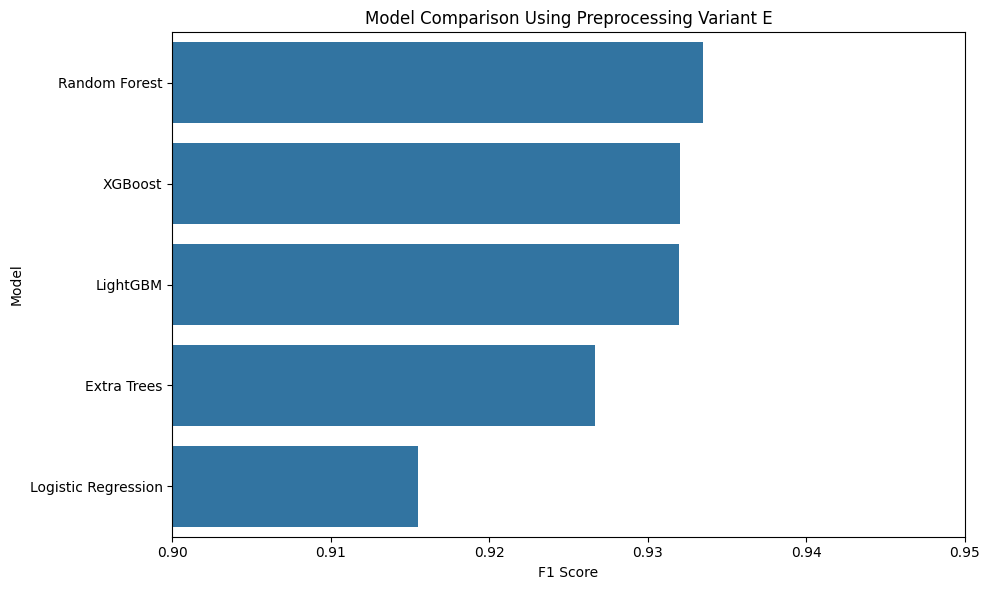

In [50]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=variant_e_results,
    x="f1_score",
    y="model"
)

plt.title("Model Comparison Using Preprocessing Variant E")
plt.xlabel("F1 Score")
plt.ylabel("Model")

plt.xlim(0.90, 0.95)

plt.tight_layout()
plt.show()

## 12. Hyperparameter Optimization

The three strongest models from the previous benchmarking stage—Random Forest,
XGBoost, and LightGBM—are further optimized to determine whether targeted
hyperparameter tuning can improve their classification performance.

The models are selected based primarily on F1-score, while ROC-AUC and the
remaining classification metrics are also considered during evaluation.

To avoid an unnecessarily large search space, a targeted hyperparameter search
is performed rather than an exhaustive search across all possible
configurations.

In [53]:
# search space for hyperparameter tuning
rf_param_distributions = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [56]:
rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=rf_param_distributions,
    n_iter=20,
    scoring="f1",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=1
)

In [57]:
print("Starting Random Forest hyperparameter search...")

rf_search.fit(
    X_train_E,
    y_train
)

print("\nBest parameters:")
print(rf_search.best_params_)

print(f"\nBest cross-validation F1: {rf_search.best_score_:.4f}")

Starting Random Forest hyperparameter search...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=  14.0s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=  10.8s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=   8.3s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=200; total time=   8.8s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=200; total time=   7.4s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=200; total time=   6.0s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=  12.0s
[CV] END max_depth=20, max_features=log2, min_sa

In [58]:
# Retrieve the best Random Forest model
best_rf_model = rf_search.best_estimator_

# Evaluate on the untouched test set
tuned_rf_results = evaluate_model(
    best_rf_model,
    X_test_E,
    y_test
)

tuned_rf_results["variant"] = "E"
tuned_rf_results["model"] = "Random Forest (Tuned)"

print("Tuned Random Forest Results:")

for metric, value in tuned_rf_results.items():
    if metric not in ["variant", "model"]:
        print(f"{metric}: {value:.4f}")

Tuned Random Forest Results:
accuracy: 0.9125
precision: 0.9814
recall: 0.8883
f1_score: 0.9326
roc_auc: 0.9857


In [59]:
baseline_rf_f1 = variant_e_results[
    variant_e_results["model"] == "Random Forest"
]["f1_score"].iloc[0]

tuned_rf_f1 = tuned_rf_results["f1_score"]

print(f"Baseline Random Forest F1: {baseline_rf_f1:.4f}")
print(f"Tuned Random Forest F1:    {tuned_rf_f1:.4f}")
print(f"Improvement:                {tuned_rf_f1 - baseline_rf_f1:+.4f}")

Baseline Random Forest F1: 0.9335
Tuned Random Forest F1:    0.9326
Improvement:                -0.0009


Targeted Random Forest hyperparameter optimization did not improve the held-out test F1-score compared with the baseline configuration. Although the tuned model achieved a higher ROC-AUC, the baseline Random Forest retained the highest test F1-score and was therefore preserved as the preferred Random Forest configuration.

In [60]:
# search space for hyperparameter tuning
xgb_param_distributions = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}

In [61]:
xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ),
    param_distributions=xgb_param_distributions,
    n_iter=20,
    scoring="f1",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=1
)

In [62]:
print("Starting XGBoost hyperparameter search...")

xgb_search.fit(
    X_train_E,
    y_train
)

print("\nBest parameters:")
print(xgb_search.best_params_)

print(f"\nBest cross-validation F1: {xgb_search.best_score_:.4f}")

Starting XGBoost hyperparameter search...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=5, min_child_weight=3, n_estimators=200, subsample=0.8; total time=   1.8s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=5, min_child_weight=3, n_estimators=200, subsample=0.8; total time=   1.3s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=5, min_child_weight=3, n_estimators=200, subsample=0.8; total time=   1.3s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=300, subsample=1.0; total time=   2.7s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=300, subsample=1.0; total time=   2.6s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=300, subsample=1.0; total time=   2.4s
[CV] END colsample_bytree=0.7, learning_rate=0.03, max_depth=4, min_child_weight=3, n_e

In [63]:
# Retrieve the best XGBoost model
best_xgb_model = xgb_search.best_estimator_

# Evaluate on the untouched test set
tuned_xgb_results = evaluate_model(
    best_xgb_model,
    X_test_E,
    y_test
)

tuned_xgb_results["variant"] = "E"
tuned_xgb_results["model"] = "XGBoost (Tuned)"

print("Tuned XGBoost Results:")

for metric, value in tuned_xgb_results.items():
    if metric not in ["variant", "model"]:
        print(f"{metric}: {value:.4f}")

Tuned XGBoost Results:
accuracy: 0.9127
precision: 0.9832
recall: 0.8869
f1_score: 0.9326
roc_auc: 0.9856


In [64]:
baseline_xgb_f1 = variant_e_results[
    variant_e_results["model"] == "XGBoost"
]["f1_score"].iloc[0]

baseline_rf_f1 = variant_e_results[
    variant_e_results["model"] == "Random Forest"
]["f1_score"].iloc[0]

tuned_xgb_f1 = tuned_xgb_results["f1_score"]

print(f"Baseline XGBoost F1: {baseline_xgb_f1:.4f}")
print(f"Tuned XGBoost F1:    {tuned_xgb_f1:.4f}")
print(f"XGBoost improvement:  {tuned_xgb_f1 - baseline_xgb_f1:+.4f}")

print()

print(f"Random Forest F1:     {baseline_rf_f1:.4f}")
print(f"Difference vs RF:     {tuned_xgb_f1 - baseline_rf_f1:+.4f}")

Baseline XGBoost F1: 0.9321
Tuned XGBoost F1:    0.9326
XGBoost improvement:  +0.0005

Random Forest F1:     0.9335
Difference vs RF:     -0.0009


Targeted XGBoost hyperparameter optimization produced a small improvement in the held-out test F1-score compared with the baseline configuration. However, despite the improvement, the tuned XGBoost model did not surpass the baseline Random Forest. The tuned XGBoost configuration was therefore retained as an improved boosting model, while the baseline Random Forest remained the overall best-performing model based on F1-score.

In [65]:
# search space for hyperparameter tuning
lgbm_param_distributions = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 5, 10, 15],
    "min_child_samples": [10, 20, 30],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

In [66]:
lgbm_search = RandomizedSearchCV(
    estimator=LGBMClassifier(
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ),
    param_distributions=lgbm_param_distributions,
    n_iter=20,
    scoring="f1",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=1
)

In [67]:
print("Starting LightGBM hyperparameter search...")

lgbm_search.fit(
    X_train_E,
    y_train
)

print("\nBest parameters:")
print(lgbm_search.best_params_)

print(f"\nBest cross-validation F1: {lgbm_search.best_score_:.4f}")

Starting LightGBM hyperparameter search...
Fitting 3 folds for each of 20 candidates, totalling 60 fits


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.7, learning_rate=0.1, max_depth=10, min_child_samples=20, n_estimators=500, num_leaves=31, subsample=1.0; total time=   3.8s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.7, learning_rate=0.1, max_depth=10, min_child_samples=20, n_estimators=500, num_leaves=31, subsample=1.0; total time=   3.5s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.7, learning_rate=0.1, max_depth=10, min_child_samples=20, n_estimators=500, num_leaves=31, subsample=1.0; total time=   3.9s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=15, min_child_samples=30, n_estimators=500, num_leaves=63, subsample=0.8; total time=   6.6s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=15, min_child_samples=30, n_estimators=500, num_leaves=63, subsample=0.8; total time=   6.0s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=15, min_child_samples=30, n_estimators=500, num_leaves=63, subsample=0.8; total time=   6.2s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=5, min_child_samples=30, n_estimators=500, num_leaves=31, subsample=1.0; total time=   2.9s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=5, min_child_samples=30, n_estimators=500, num_leaves=31, subsample=1.0; total time=   2.7s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=5, min_child_samples=30, n_estimators=500, num_leaves=31, subsample=1.0; total time=   2.7s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=5, min_child_samples=20, n_estimators=300, num_leaves=63, subsample=0.7; total time=   1.8s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=5, min_child_samples=20, n_estimators=300, num_leaves=63, subsample=0.7; total time=   1.7s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=5, min_child_samples=20, n_estimators=300, num_leaves=63, subsample=0.7; total time=   1.9s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=-1, min_child_samples=10, n_estimators=500, num_leaves=15, subsample=0.7; total time=   2.8s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=-1, min_child_samples=10, n_estimators=500, num_leaves=15, subsample=0.7; total time=   2.7s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=-1, min_child_samples=10, n_estimators=500, num_leaves=15, subsample=0.7; total time=   3.1s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=1.0, learning_rate=0.03, max_depth=10, min_child_samples=30, n_estimators=300, num_leaves=15, subsample=0.7; total time=   2.1s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=1.0, learning_rate=0.03, max_depth=10, min_child_samples=30, n_estimators=300, num_leaves=15, subsample=0.7; total time=   1.9s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=1.0, learning_rate=0.03, max_depth=10, min_child_samples=30, n_estimators=300, num_leaves=15, subsample=0.7; total time=   1.9s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=5, min_child_samples=30, n_estimators=200, num_leaves=63, subsample=0.8; total time=   1.3s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=5, min_child_samples=30, n_estimators=200, num_leaves=63, subsample=0.8; total time=   1.2s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=5, min_child_samples=30, n_estimators=200, num_leaves=63, subsample=0.8; total time=   1.2s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=15, min_child_samples=10, n_estimators=500, num_leaves=31, subsample=1.0; total time=   3.9s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=15, min_child_samples=10, n_estimators=500, num_leaves=31, subsample=1.0; total time=   4.8s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=15, min_child_samples=10, n_estimators=500, num_leaves=31, subsample=1.0; total time=   5.0s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=-1, min_child_samples=10, n_estimators=200, num_leaves=63, subsample=0.7; total time=   2.7s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=-1, min_child_samples=10, n_estimators=200, num_leaves=63, subsample=0.7; total time=   2.9s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=-1, min_child_samples=10, n_estimators=200, num_leaves=63, subsample=0.7; total time=   3.3s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=10, min_child_samples=10, n_estimators=500, num_leaves=63, subsample=0.7; total time=   5.8s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=10, min_child_samples=10, n_estimators=500, num_leaves=63, subsample=0.7; total time=   5.9s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=10, min_child_samples=10, n_estimators=500, num_leaves=63, subsample=0.7; total time=   5.8s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=1.0, learning_rate=0.03, max_depth=10, min_child_samples=20, n_estimators=200, num_leaves=15, subsample=1.0; total time=   1.4s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=1.0, learning_rate=0.03, max_depth=10, min_child_samples=20, n_estimators=200, num_leaves=15, subsample=1.0; total time=   1.3s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=1.0, learning_rate=0.03, max_depth=10, min_child_samples=20, n_estimators=200, num_leaves=15, subsample=1.0; total time=   1.5s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.7, learning_rate=0.03, max_depth=5, min_child_samples=20, n_estimators=500, num_leaves=31, subsample=0.8; total time=   2.7s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.7, learning_rate=0.03, max_depth=5, min_child_samples=20, n_estimators=500, num_leaves=31, subsample=0.8; total time=   2.5s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.7, learning_rate=0.03, max_depth=5, min_child_samples=20, n_estimators=500, num_leaves=31, subsample=0.8; total time=   2.8s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=-1, min_child_samples=30, n_estimators=300, num_leaves=15, subsample=1.0; total time=   1.5s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=-1, min_child_samples=30, n_estimators=300, num_leaves=15, subsample=1.0; total time=   1.6s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=-1, min_child_samples=30, n_estimators=300, num_leaves=15, subsample=1.0; total time=   1.8s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.7, learning_rate=0.1, max_depth=5, min_child_samples=20, n_estimators=300, num_leaves=31, subsample=0.8; total time=   1.9s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.7, learning_rate=0.1, max_depth=5, min_child_samples=20, n_estimators=300, num_leaves=31, subsample=0.8; total time=   2.0s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.7, learning_rate=0.1, max_depth=5, min_child_samples=20, n_estimators=300, num_leaves=31, subsample=0.8; total time=   2.0s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=5, min_child_samples=20, n_estimators=300, num_leaves=63, subsample=0.7; total time=   1.7s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=5, min_child_samples=20, n_estimators=300, num_leaves=63, subsample=0.7; total time=   1.6s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=5, min_child_samples=20, n_estimators=300, num_leaves=63, subsample=0.7; total time=   1.8s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=10, min_child_samples=30, n_estimators=200, num_leaves=31, subsample=0.7; total time=   1.7s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=10, min_child_samples=30, n_estimators=200, num_leaves=31, subsample=0.7; total time=   1.7s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=10, min_child_samples=30, n_estimators=200, num_leaves=31, subsample=0.7; total time=   1.8s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=15, min_child_samples=10, n_estimators=500, num_leaves=15, subsample=0.7; total time=   2.5s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=15, min_child_samples=10, n_estimators=500, num_leaves=15, subsample=0.7; total time=   2.6s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=15, min_child_samples=10, n_estimators=500, num_leaves=15, subsample=0.7; total time=   2.6s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=10, min_child_samples=10, n_estimators=200, num_leaves=31, subsample=0.7; total time=   1.6s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=10, min_child_samples=10, n_estimators=200, num_leaves=31, subsample=0.7; total time=   1.8s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=10, min_child_samples=10, n_estimators=200, num_leaves=31, subsample=0.7; total time=   2.0s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=15, min_child_samples=10, n_estimators=200, num_leaves=15, subsample=0.7; total time=   1.3s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=15, min_child_samples=10, n_estimators=200, num_leaves=15, subsample=0.7; total time=   1.5s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.03, max_depth=15, min_child_samples=10, n_estimators=200, num_leaves=15, subsample=0.7; total time=   1.3s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.7, learning_rate=0.1, max_depth=15, min_child_samples=30, n_estimators=300, num_leaves=15, subsample=0.8; total time=   1.8s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.7, learning_rate=0.1, max_depth=15, min_child_samples=30, n_estimators=300, num_leaves=15, subsample=0.8; total time=   1.9s


c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.7, learning_rate=0.1, max_depth=15, min_child_samples=30, n_estimators=300, num_leaves=15, subsample=0.8; total time=   1.6s

Best parameters:
{'subsample': 0.7, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 30, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

Best cross-validation F1: 0.9234


In [68]:
# Predict using the best LightGBM model
best_lgbm = lgbm_search.best_estimator_

y_pred_lgbm_tuned = best_lgbm.predict(X_test_E)

y_proba_lgbm_tuned = best_lgbm.predict_proba(X_test_E)[:, 1]

# Calculate metrics
lgbm_tuned_results = {
    "accuracy": accuracy_score(y_test, y_pred_lgbm_tuned),
    "precision": precision_score(y_test, y_pred_lgbm_tuned),
    "recall": recall_score(y_test, y_pred_lgbm_tuned),
    "f1_score": f1_score(y_test, y_pred_lgbm_tuned),
    "roc_auc": roc_auc_score(y_test, y_proba_lgbm_tuned)
}

print("Tuned LightGBM Results:\n")

for metric, value in lgbm_tuned_results.items():
    print(f"{metric}: {value:.4f}")

print(f"\nBaseline LightGBM F1: {0.9320:.4f}")
print(f"Tuned LightGBM F1:    {lgbm_tuned_results['f1_score']:.4f}")
print(
    f"LightGBM improvement: "
    f"{lgbm_tuned_results['f1_score'] - 0.9320:+.4f}"
)

print(f"\nRandom Forest F1:     {0.9335:.4f}")
print(
    f"Difference vs RF:     "
    f"{lgbm_tuned_results['f1_score'] - 0.9335:+.4f}"
)

c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Askari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Tuned LightGBM Results:

accuracy: 0.9126
precision: 0.9827
recall: 0.8871
f1_score: 0.9325
roc_auc: 0.9854

Baseline LightGBM F1: 0.9320
Tuned LightGBM F1:    0.9325
LightGBM improvement: +0.0005

Random Forest F1:     0.9335
Difference vs RF:     -0.0010


Targeted LightGBM hyperparameter optimization produced a marginal improvement in the held-out test F1-score, increasing performance from 0.9320 to 0.9325. However, this improvement remained below the baseline Random Forest F1-score of 0.9335. Therefore, although tuning improved LightGBM slightly, the baseline Random Forest configuration remained the strongest overall model.

In [71]:
# Recreate the winning baseline Random Forest
final_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_E, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [72]:
y_pred_final = final_model.predict(X_test_E)
y_proba_final = final_model.predict_proba(X_test_E)[:, 1]

print(f"Final Random Forest F1: {f1_score(y_test, y_pred_final):.4f}")

Final Random Forest F1: 0.9335


In [73]:
print(
    classification_report(
        y_test,
        y_pred_final
    )
)

              precision    recall  f1-score   support

           0       0.81      0.96      0.88     56000
           1       0.98      0.89      0.93    119341

    accuracy                           0.91    175341
   macro avg       0.89      0.93      0.91    175341
weighted avg       0.92      0.91      0.92    175341



[[ 53871   2129]
 [ 13023 106318]]


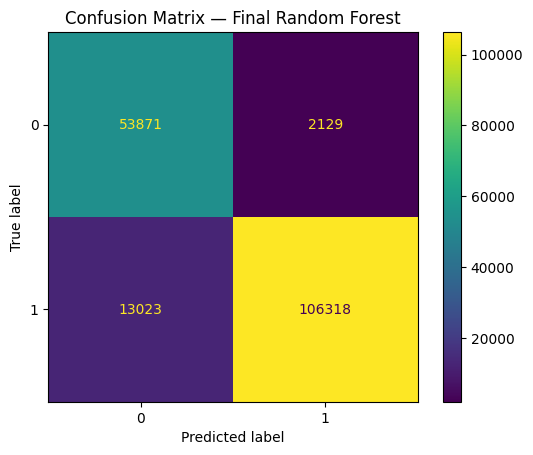

In [76]:
cm = confusion_matrix(
    y_test,
    y_pred_final
)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Confusion Matrix — Final Random Forest")
plt.show()

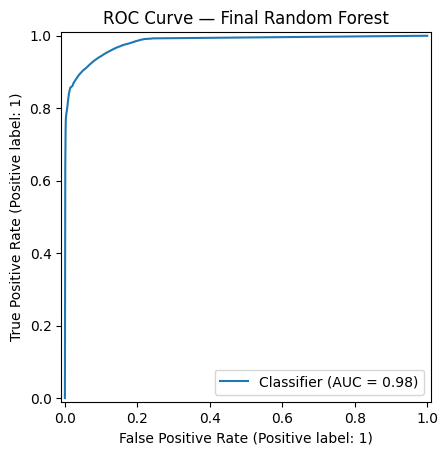

In [79]:
RocCurveDisplay.from_predictions(
    y_test,
    y_proba_final
)

plt.title("ROC Curve — Final Random Forest")
plt.show()

# 9. Feature Importance Analysis

This section examines the relative importance of input features in the final Random Forest model. Feature importance analysis helps identify which network traffic characteristics contribute most strongly to the model's classification decisions.

The analysis is performed using the feature importance scores learned by the Random Forest during training.

In [84]:
preprocessor_E = preprocessing_variants["E"]

feature_names_E = preprocessor_E.get_feature_names_out()

print("Number of transformed features:", len(feature_names_E))
print(feature_names_E[:20])

Number of transformed features: 177
['numeric__dur' 'numeric__sbytes' 'numeric__dbytes' 'numeric__rate'
 'numeric__sttl' 'numeric__dttl' 'numeric__sload' 'numeric__dload'
 'numeric__sinpkt' 'numeric__dinpkt' 'numeric__sjit' 'numeric__djit'
 'numeric__swin' 'numeric__stcpb' 'numeric__dtcpb' 'numeric__synack'
 'numeric__ackdat' 'numeric__smean' 'numeric__dmean'
 'numeric__trans_depth']


In [85]:
feature_importance = pd.DataFrame({
    "feature": feature_names_E,
    "importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

feature_importance.head(20)

,feature,importance
0,numeric__sbytes,0.073695
1,numeric__ct_srv_dst,0.068267
2,numeric__sttl,0.062276
3,numeric__smean,0.061499
4,numeric__ct_state_ttl,0.054040
5,numeric__sload,0.052749
6,numeric__dur,0.046171
7,numeric__dbytes,0.043603
8,numeric__rate,0.042469
9,numeric__ct_dst_sport_ltm,0.041732


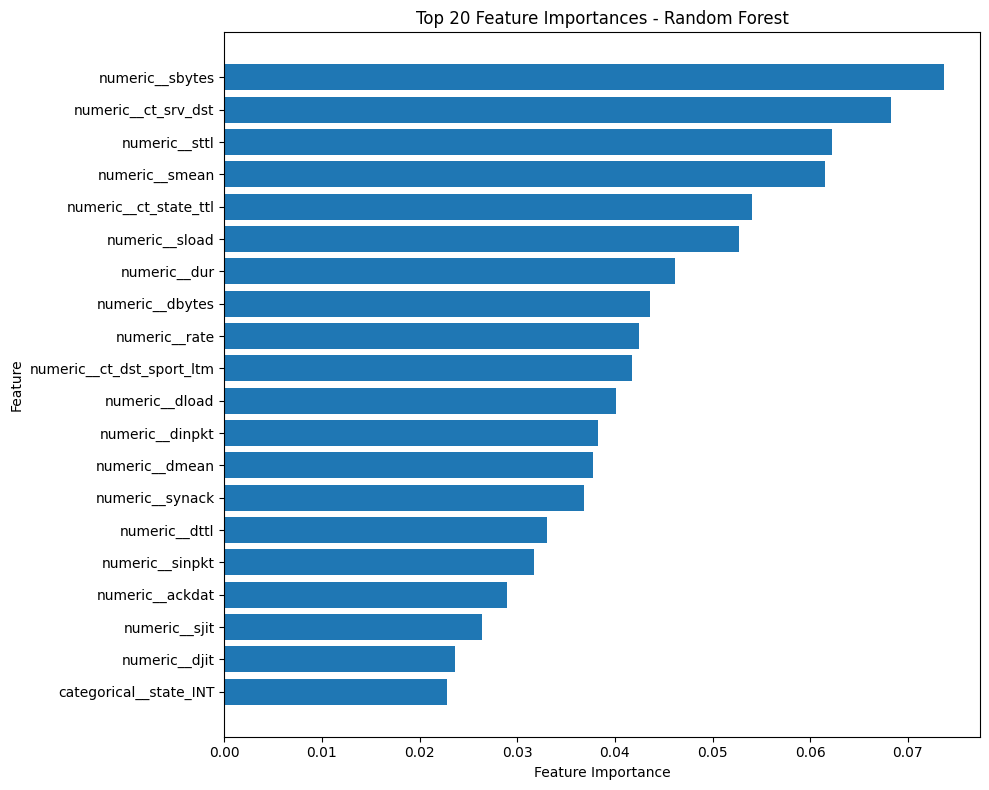

In [86]:
top_n = 20

top_features = feature_importance.head(top_n).sort_values(
    by="importance",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances - Random Forest")

plt.tight_layout()
plt.show()

## Feature Importance Interpretation

The feature importance analysis shows that the final Random Forest model relies primarily on a combination of traffic volume, connection behaviour, packet timing, and network state characteristics.

The most influential feature was `sbytes`, followed by `ct_srv_dst`, `sttl`, `smean`, `ct_state_ttl`, and `sload`. These features capture important aspects of network traffic, including the volume of transmitted data, connection frequency, packet and protocol behaviour, time-to-live characteristics, and traffic intensity.

Several representative features retained during the correlation-based feature reduction process also appear among the most important predictors. This supports the effectiveness of the feature selection strategy, as highly correlated groups were reduced while preserving informative representative variables.

The importance distribution also demonstrates that the model does not rely exclusively on a single feature. Instead, predictions are influenced by multiple complementary characteristics of network traffic, which contributes to the robustness of the final model.

It should be noted that these importance scores are based on impurity reduction within the Random Forest. Therefore, they represent the relative contribution of features to the model's decision-making process rather than establishing a causal relationship with the target variable.